# Hypothesis Testing Demo

This notebook demonstrates the basic workflow of **Hypothesis Testing** using the college pass-percentage example from the notes.

### Problem

A college claims that the average pass percentage is **85%**.

- Sample size: $n = 100$
- Sample mean: $\bar{x} = 90\%$
- Population standard deviation: $\sigma = 4\%$
- Hypothesized population mean: $\mu_0 = 85\%$
- Significance level: $\alpha = 0.05$

We want to determine whether the college's average pass percentage is **different from 85%**.

## 1. Define the Hypotheses

Because the question asks whether the population mean is **different** from 85%, this is a **two-tailed test**.

$$
H_0: \mu = 85
$$

$$
H_1: \mu \neq 85
$$

- $H_0$ → Null Hypothesis / default assumption
- $H_1$ → Alternate Hypothesis


In [1]:
import math
from scipy import stats
import matplotlib.pyplot as plt

n = 100
sample_mean = 90
population_mean = 85
population_std = 4
alpha = 0.05

print(f"Sample size (n): {n}")
print(f"Sample mean (x̄): {sample_mean}%")
print(f"Hypothesized mean (μ₀): {population_mean}%")
print(f"Population standard deviation (σ): {population_std}%")
print(f"Significance level (α): {alpha}")

Sample size (n): 100
Sample mean (x̄): 90%
Hypothesized mean (μ₀): 85%
Population standard deviation (σ): 4%
Significance level (α): 0.05


## 2. Calculate the Z-Statistic

Since the population standard deviation is known, we use the **one-sample Z-test**.

The formula is:

$$
Z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}}
$$

where:

- $\bar{x}$ = sample mean
- $\mu_0$ = hypothesized population mean
- $\sigma$ = population standard deviation
- $n$ = sample size

In [2]:
standard_error = population_std / math.sqrt(n)
z_stat = (sample_mean - population_mean) / standard_error

print(f"Standard Error = {standard_error:.4f}")
print(f"Z-statistic = {z_stat:.4f}")

Standard Error = 0.4000
Z-statistic = 12.5000


### Interpretation of the Z-statistic

The calculated Z-statistic tells us how many standard errors the sample mean is away from the hypothesized population mean.

A large absolute Z-value provides stronger evidence against $H_0$.

## 3. Calculate the Two-Tailed p-value

For a two-tailed Z-test:

$$
p = 2P(Z \geq |z|)
$$

We calculate the p-value using SciPy.

In [3]:
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print(f"p-value = {p_value:.10f}")

p-value = 0.0000000000


## 4. Make the Decision

Decision rule:

- If **p-value ≤ α** → Reject $H_0$
- If **p-value > α** → Fail to reject $H_0$

Here, $\alpha = 0.05$.

In [4]:
if p_value <= alpha:
    decision = "Reject H₀"
    conclusion = "There is sufficient evidence that the average pass percentage is different from 85%."
else:
    decision = "Fail to reject H₀"
    conclusion = "There is insufficient evidence that the average pass percentage is different from 85%."

print(f"Decision: {decision}")
print(f"Conclusion: {conclusion}")

Decision: Reject H₀
Conclusion: There is sufficient evidence that the average pass percentage is different from 85%.


## 5. Critical Value Approach

For a two-tailed test with $\alpha = 0.05$, the critical Z-values are approximately:

$$
Z_{critical} = \pm 1.96
$$

Decision rule:

$$
|Z| > 1.96 \Rightarrow \text{Reject } H_0
$$

$$
|Z| \leq 1.96 \Rightarrow \text{Fail to reject } H_0
$$

In [5]:
critical_value = stats.norm.ppf(1 - alpha / 2)

print(f"Critical value = ±{critical_value:.4f}")
print(f"Absolute Z-statistic = {abs(z_stat):.4f}")

if abs(z_stat) > critical_value:
    print("Decision: Reject H₀")
else:
    print("Decision: Fail to reject H₀")

Critical value = ±1.9600
Absolute Z-statistic = 12.5000
Decision: Reject H₀


## 6. Verify Using SciPy

SciPy provides a direct function for the one-sample Z-test calculation when the population standard deviation is known.

The p-value can also be calculated directly from the standard normal distribution.

In [6]:
z_stat_scipy = (sample_mean - population_mean) / (population_std / math.sqrt(n))
p_value_scipy = 2 * stats.norm.sf(abs(z_stat_scipy))

print(f"Z-statistic using SciPy: {z_stat_scipy:.4f}")
print(f"Two-tailed p-value using SciPy: {p_value_scipy:.10f}")

Z-statistic using SciPy: 12.5000
Two-tailed p-value using SciPy: 0.0000000000


## 7. Visualize the Test

The plot below shows the standard normal distribution, the critical regions, and the calculated Z-statistic.

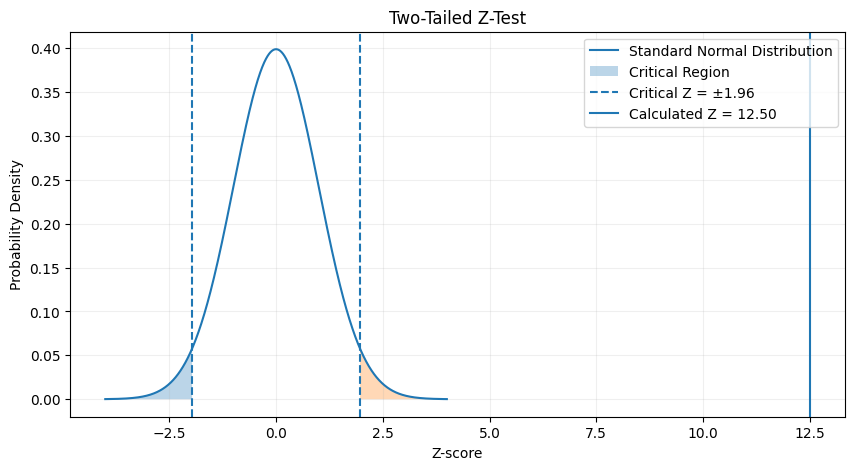

In [7]:
import numpy as np

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label="Standard Normal Distribution")

left_tail = x <= -critical_value
right_tail = x >= critical_value
plt.fill_between(x[left_tail], y[left_tail], alpha=0.3, label="Critical Region")
plt.fill_between(x[right_tail], y[right_tail], alpha=0.3)

plt.axvline(-critical_value, linestyle="--", label=f"Critical Z = ±{critical_value:.2f}")
plt.axvline(critical_value, linestyle="--")
plt.axvline(z_stat, linestyle="-", label=f"Calculated Z = {z_stat:.2f}")

plt.title("Two-Tailed Z-Test")
plt.xlabel("Z-score")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 8. Final Interpretation

The calculated Z-statistic is approximately:

$$
Z = 12.5
$$

The p-value is extremely small and is much less than $0.05$.

Therefore, we **reject the Null Hypothesis ($H_0$)**.

**Conclusion:** There is strong statistical evidence that the average pass percentage of the college is different from 85%.

> Note: In formal statistical writing, we generally say **"reject $H_0$"** or **"fail to reject $H_0$"** rather than treating the null hypothesis as proven true.

## Key Takeaways

- Hypothesis testing uses sample data to make inferences about a population.
- $H_0$ represents the default assumption.
- $H_1$ represents the alternative claim.
- A **two-tailed test** is used when the question asks whether a parameter is different from a specified value.
- A **p-value** helps determine whether the observed evidence is statistically significant.
- For this example, the evidence leads us to reject $H_0$.